<a href="https://colab.research.google.com/github/vg137/ibd-causal-multiomics/blob/main/nb1_snp2genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction and setup

In this notebook, we first choose a GWAS (Genome-Wide Association Study) on Inflammatory Bowel Disease (IBD). Then, we map the significant SNPs (Single Nucleotide Polymorphisms) to genes which are annotated in the latest genome assembly, GRCh38.p14.

In [2]:
# For accessing the datasets stored in the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# nb1_functions file contains many helper functions used in this notebook
import sys
project_dir = "/content/drive/MyDrive/Colab Notebooks/Genomics project"
sys.path.append(project_dir)
import nb1_functions

In [4]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.stats import chi2

In [5]:
# file locations and names
data_dir = "ibd_data"
gwas_raw_subdir = "gwas/raw" # directory with the raw gwas data
gwas_name = "GCST90292538"
gwas_raw_filepath = f"{project_dir}/{data_dir}/{gwas_raw_subdir}/{gwas_name}_harmonised/{gwas_name}.h.tsv.gz"

The metadata about this GWAS study can be found in the `yaml` file that comes with the compressed GWAS data file

In [6]:
gwas_metadata_filepath = f"{project_dir}/{data_dir}/{gwas_raw_subdir}/{gwas_name}_harmonised/{gwas_name}.h.tsv.gz-meta.yaml"
with open(gwas_metadata_filepath, "r") as f:
    print(f.read())

coordinate_system: 1-based
data_file_md5sum: c986ab6711c3149e5923f3c5ff5480d0
data_file_name: GCST90292538.h.tsv.gz
date_metadata_last_modified: 2024-09-24
file_type: GWAS-SSF v1.0
genome_assembly: GRCh38
genotyping_technology:
- Genome-wide genotyping array
gwas_catalog_api: https://www.ebi.ac.uk/gwas/rest/api/studies/GCST90292538
gwas_id: GCST90292538
harmonisation_reference: ftp://ftp.ensembl.org/pub/release-95/fasta/homo_sapiens/dna/
is_harmonised: true
is_sorted: true
ontology_mapping:
- ''
samples:
- case_control_study: true
  sample_ancestry_category:
  - East Asian
  sample_size: 29849
- case_control_study: true
  sample_ancestry_category:
  - European
  sample_size: 368819
sex: combined
trait_description:
- Inflammatory bowel disease



## Generating the parquet file

The GWAS datasets are usually very large (millions of SNPs), we will convert it to a better suited format called [parquet](https://en.wikipedia.org/wiki/Apache_Parquet)

In [7]:
gwas_parquet_subdir = "gwas/parquet"
gwas_parquet_filepath = f"{project_dir}/{data_dir}/{gwas_parquet_subdir}/{gwas_name}.parquet"

Uncomment the following block, if the parquet file has not been generated yet or is not available

In [8]:
# nb1_functions.create_parquet_file(gwas_raw_filepath, gwas_parquet_filepath)

Comment the above block after it runs successfully

# Quality control

## Basic info and sanity checks

Let's see some metadata that is automatically generated when a parquet file is created

In [9]:
gwas_pf_metadata = pq.read_metadata(gwas_parquet_filepath) # metadata like number of rows and columns
gwas_pf_metadata.num_rows

21619289

Total rows = 21,619,289 $\implies$ Around 22 million different SNPs were studied

Let us see all the column names in the file

In [10]:
gwas_pf_schema = pq.read_schema(gwas_parquet_filepath)
gwas_pf_schema.names

['chromosome',
 'base_pair_location',
 'effect_allele',
 'other_allele',
 'beta',
 'standard_error',
 'effect_allele_frequency',
 'p_value',
 'variant_id',
 'rsid',
 'FreqSE',
 'MinFreq',
 'MaxFreq',
 'Direction',
 'HetISq',
 'HetChiSq',
 'HetDf',
 'HetPVal',
 'hm_coordinate_conversion',
 'hm_code']

In [11]:
table = pq.read_table(gwas_parquet_filepath, columns=["chromosome"])
chr_arr = table.column("chromosome").unique().to_pylist()
chr_arr

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

From the above output, we learn that all 22 pairs of autosomal chromosomes are studied but not the sex or the mitochondrial chromosomes

## Missing values

In [12]:
important_columns_gwas = ["chromosome", "base_pair_location", "p_value"]

null_counts = {col : 0 for col in important_columns_gwas}

for batch in nb1_functions.get_parquet_iterator(gwas_parquet_filepath, columns=important_columns_gwas):
    for col in important_columns_gwas:
        null_counts[col] += batch[col].null_count

for col in important_columns_gwas:
    print(f"Missing values in column {col}: {null_counts[col]}")

Missing values in column chromosome: 0
Missing values in column base_pair_location: 0
Missing values in column p_value: 0


Above output shows that none of the important parameters are missing

## Non-SNP rows

We want to check whether all the rows correspond to SNPs or not

In [13]:
num_non_snps = nb1_functions.get_num_non_snps(gwas_parquet_filepath)
num_non_snps

1361640

So, the data has 1361640 rows of non-SNPs in a total of 21619289 rows. We want to restrict to SNPs for this notebook. To this end, we create a new parquet with only the SNP data

In [14]:
snp_parquet_filepath = gwas_parquet_filepath.replace(".parquet", "_snp.parquet")

Uncomment the following line to create a parquet file with only SNP rows

In [15]:
# nb1_functions.create_snp_parquet_file(parquet_filepath, snp_parquet_filepath)

We will assume below that such a file exists at the above filepath

In [16]:
snp_pf_metadata = pq.read_metadata(snp_parquet_filepath)

As a sanity check, we can check that no other rows got deleted

In [17]:
snp_pf_metadata.num_rows + num_non_snps == gwas_pf_metadata.num_rows

True

## p-value histogram

We will use the standard genome-wide significance threshold (GWST) of $5 \times 10^{-8}$ for the entire analysis

In [18]:
GWST = 5e-8 # Genome-wide significance threshold

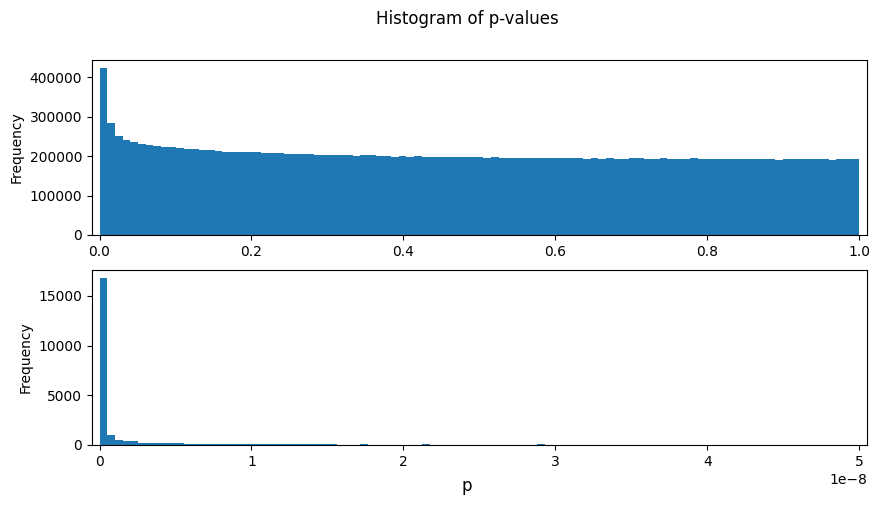

In [19]:
fig, axs = plt.subplots(2, figsize=(10, 5));

# histogram of all p-values
num_bins_1 = 100
bins_1 = np.linspace(0, 1, num_bins_1)
counts_1 = np.zeros(num_bins_1 - 1)

# histogram of p-values below gwst
num_bins_2 = 100
bins_2 = np.linspace(0, GWST, num_bins_2)
counts_2 = np.zeros(num_bins_2 - 1)

p_values = pq.read_table(snp_parquet_filepath, columns=["p_value"])["p_value"].to_numpy()
counts_1 = np.histogram(p_values, bins=bins_1)[0]
counts_2 = np.histogram(p_values[p_values < GWST], bins=bins_2)[0]

axs[0].hist(bins_1[:-1], bins_1, weights=counts_1)
axs[0].set_ylabel("Frequency")
axs[0].margins(x=0.01)

axs[1].hist(bins_2[:-1], bins_2, weights=counts_2)
axs[1].set_ylabel("Frequency")
axs[1].margins(x=0.01)

fig.supxlabel("p")
fig.suptitle("Histogram of p-values");

The p-values are distributed almost uniformly apart from spikes near 0. This means that few of the SNPs have very low p-values indicating that some of the SNPs may be strong causal candidates. The second histogram shows this more clearly because only the p-values below the genome-wide significance threshold are counted

## Manhattan plot

In order to generate the Manhattan plot, we need to find the maximum and minimum SNP base pair locations within each chromosome

In [20]:
chr_max_locations = nb1_functions.get_chr_max_locations(snp_parquet_filepath, chr_arr=chr_arr)
chr_min_locations = nb1_functions.get_chr_min_locations(snp_parquet_filepath, chr_arr=chr_arr)

# The maximum values are used to calculate the offsets for every chromosome
# to ensure that the SNPs are plotted in the right chromosome bin
bp_loc_offset = chr_max_locations.cumsum() - chr_max_locations

In [21]:
manhattan_columns = ["chromosome", "base_pair_location", "p_value"]

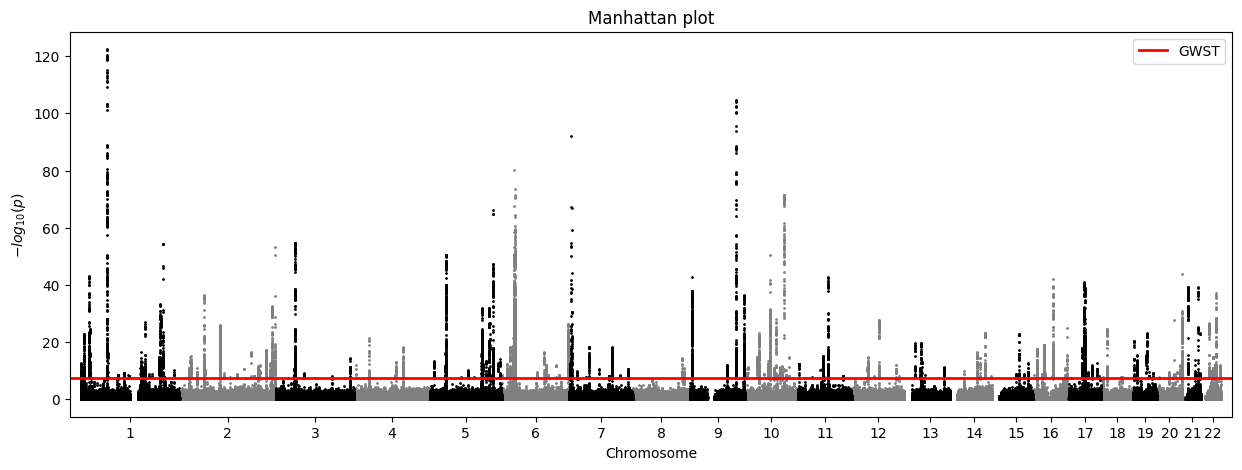

In [22]:
fig, ax = plt.subplots(figsize=(15, 5))

colors = np.array(["grey", "black"]) # the neighbouring chromosomes will alternate between these colors

# For faster plotting, we will split the SNPs into two groups: significant and background
# Significant SNPs have p-values < gwst
# The rest of the SNPs are background
# We will only plot a small fraction of the background SNPs

background_fraction = 0.05 # fraction of the background (i.e. below gwst) p-values to plot

for batch in nb1_functions.get_parquet_iterator(snp_parquet_filepath, columns=manhattan_columns):
    # converting everything to numpy arrays
    chrom_arr = batch["chromosome"].to_numpy()
    bp_arr = batch["base_pair_location"].to_numpy()
    pval_arr = batch["p_value"].to_numpy()

    signif_mask = pval_arr < GWST
    signif_size = len(signif_mask)
    signif_indices = np.nonzero(signif_mask)[0] # get the indices of the significant SNPs

    background_mask = ~signif_mask
    background_size = background_mask.sum()
    background_indices = np.nonzero(background_mask)[0] # get the indices of the background SNPs
    background_indices = np.random.choice(background_indices,
                                            size=int(background_size * background_fraction),
                                            replace=False
                                         )

    relevant_indices = np.concatenate([signif_indices, background_indices])

    # Scatter plot becomes slow if the c option has to deal with large arrays
    # It is actually way more efficient to find the indices of all the SNPS
    # which will have the first color, plot them with scatter by setting
    # option c to that color, and then doing the same for the second color
    for color_parity in [0, 1]:
        color_parity_indices = relevant_indices[(chrom_arr[relevant_indices] % 2) == color_parity]

        ax.scatter(bp_arr[color_parity_indices] + bp_loc_offset[chrom_arr[color_parity_indices] - 1],
                    -np.log10(pval_arr[color_parity_indices]),
                    s=1,
                    c=colors[color_parity],
                    rasterized=True
                )

xtick_locs = (chr_min_locations + chr_max_locations)/2 + bp_loc_offset # this formula ensures the ticks are
                                                                       # exactly at the center of chromosomes
xtick_labels = chr_arr
ax.set_xticks(xtick_locs)
ax.set_xticklabels(xtick_labels)
ax.axhline(y=-np.log10(GWST), color="red", linestyle="-", linewidth=2, label="GWST")
ax.margins(x=0.01)
ax.set_xlabel("Chromosome")
ax.set_ylabel(r"$-log_{10}(p)$")
ax.set_title("Manhattan plot")
ax.legend(loc="upper right");

## QQ plot

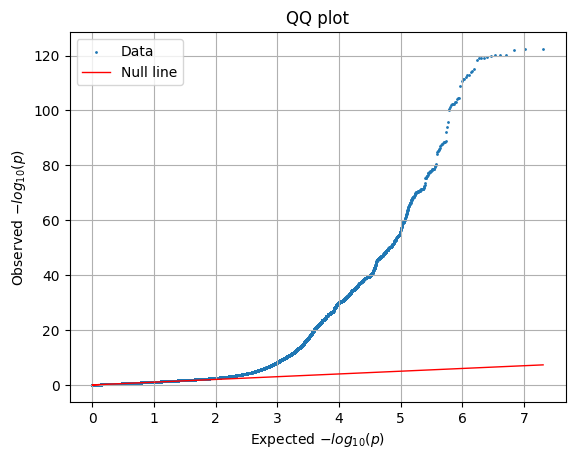

In [23]:
p_values = pq.read_table(snp_parquet_filepath, columns=["p_value"])["p_value"].to_numpy()
num_p_values = len(p_values)
log_p_values = -np.log10(np.sort(p_values))

background_fraction = 0.05 # fraction of the background (i.e. below gwst) p-values to plot

signif_mask = log_p_values > -np.log10(GWST)
signif_indices = np.nonzero(signif_mask)[0]

background_mask = ~signif_mask
background_size = background_mask.sum()
background_indices = np.nonzero(background_mask)[0]
background_indices = np.random.choice(background_indices,
                                        size=int(background_size * background_fraction),
                                        replace=False
                                     )

relevant_indices = np.concatenate([signif_indices, background_indices])
expected_log_p_values = -np.log10((relevant_indices + 1)/(num_p_values + 1))
observed_log_p_values = log_p_values[relevant_indices]

plt.scatter(expected_log_p_values, observed_log_p_values, s=1)
plt.plot(expected_log_p_values, expected_log_p_values, color="red", lw=1)  # null line
plt.xlabel(r"Expected $-log_{10}(p)$")
plt.ylabel(r"Observed $-log_{10}(p)$")
plt.title("QQ plot")
plt.legend(["Data", "Null line"], loc="upper left")
plt.grid()

Such early and large deviations from the null line is usually expected in very large GWAS studies and for highly polygenic traits like IBD. We can look at the publication associated with the study to understand this more.

# SNP to gene mapping

## Annotations

From the metadata file above, we know that the GWAS study followed the GRCh38 genome assembly. We will use the latest patch, GRCh38.p14, of the same assembly in the following

In [24]:
annotations_raw_subdir = "annotations/raw"
annotations_filename = "gencode.v49.annotation"
annotations_raw_filepath = f"{project_dir}/{data_dir}/{annotations_raw_subdir}/{annotations_filename}.gtf.gz"

In [25]:
annotations_parquet_subdir = "annotations/parquet"
annotations_parquet_filepath = f"{project_dir}/{data_dir}/{annotations_parquet_subdir}/{annotations_filename}.parquet"

Uncomment the following block to create a parquet file with the annotations

In [26]:
# nb1_functions.create_annotations_parquet_file(annotations_raw_filepath, annotations_parquet_filepath)

Comment the above block after running it

In [27]:
annotations_pf_metadata = pq.read_metadata(annotations_parquet_filepath)
annotations_pf_metadata

  created_by: parquet-cpp-arrow version 18.1.0
  num_columns: 8
  num_rows: 7750154
  num_row_groups: 78
  format_version: 2.6
  serialized_size: 61423

In [28]:
annotations_pf_schema = pq.read_schema(annotations_parquet_filepath)
annotations_pf_schema.names

['chromosome',
 'feature',
 'start',
 'end',
 'strand',
 'gene_id',
 'gene_name',
 'gene_type']

For our purposes, only the following columns are important

We will only work with rows which are marked as genes as we want to map SNP to genes

In [29]:
annotations_pf = pq.read_table(annotations_parquet_filepath, filters=[("feature", "==", "gene")])

In [30]:
annotations_df = annotations_pf.to_pandas()
annotations_df.shape[0]

78691

So, we have 78691 genes to work with

In [31]:
plus_strand_mask = annotations_df["strand"] == "+"
annotations_df["tss"] = np.where(plus_strand_mask, annotations_df["start"], annotations_df["end"])

## Mapping

We will assign the gene which has the closest TSS (Trancription Start Site) to those SNPs which are significant i.e. their p-values must be less than the gwst. So, let us start by filtering the significant SNPs

In [32]:
signif_snps_df = pq.read_table(snp_parquet_filepath,
                                columns=important_columns_gwas,
                                filters=[("p_value", "<", GWST)]
                              ).to_pandas()

Now, we just use a function to add the information about the gene assigned to each significant SNP

In [33]:
nb1_functions.add_assigned_gene_info(signif_snps_df, annotations_df)

Finally, we will save the above DataFrame with the mapped genes for future use

In [34]:
snp2gene_subdir = "snp2gene"
snp2gene_filepath = f"{project_dir}/{data_dir}/{snp2gene_subdir}/{gwas_name}_snp2gene.parquet"

In [35]:
signif_snps_df.to_parquet(snp2gene_filepath,
                            engine="pyarrow",
                            compression="zstd",
                            index=False,
                        )

Let us check the saved file by loading it

In [36]:
snp2gene_pf = pq.read_table(snp2gene_filepath)
snp2gene_pf.to_pandas().head()

,chromosome,base_pair_location,p_value,distance_to_assigned_gene,assigned_gene_id,assigned_gene_name,assigned_gene_type
0,1,1215852,2.250000e-09,1699.0,ENSG00000186827.12,TNFRSF4,protein_coding
1,1,1216593,8.490000e-10,2440.0,ENSG00000186827.12,TNFRSF4,protein_coding
2,1,1221049,7.534000e-10,6896.0,ENSG00000186827.12,TNFRSF4,protein_coding
3,1,1238902,1.230000e-08,32.0,ENSG00000078808.21,SDF4,protein_coding
4,1,1246371,6.517000e-09,351.0,ENSG00000184163.3,C1QTNF12,protein_coding


We have successfully mapped the significant SNPs to genes (with the closest TSS). This data will be used for further analysis in other notebooks.